# Model Validation — VIX

Rigorous statistical validation of 7 IVS models against market data for **VIX**.

**Models:** MLP, MLP-log, MLP-log-arb, Conv, Conv-log, Conv-log-arb, Heston  
**Sections:**
0. Config & Load & Align
1. Error Distribution Analysis
2. Signed Bias (Mean-Error Heatmaps)
3. MAPE / Relative Error
4. KS Test Per-Cell
5. Diebold-Mariano Pairwise Significance
6. Backtesting (Exceedance + Kupiec POF + Traffic Light)
7. Regime Conditioning
8. Arbitrage Violation Counting
9. Surface Smoothness

**Prerequisites:** Run `python scripts/run_pipeline.py --ticker VIX --stages eval heston compare`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import json
from pathlib import Path
from collections import OrderedDict
from scipy import stats
from scipy.stats import ks_2samp, chi2

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 6)

TICKER = "VIX"
ROOT = Path("../../..")
EVAL_DIR = ROOT / "artifacts" / "eval" / TICKER
HESTON_DIR = ROOT / "data" / "processed" / "heston" / "surfaces"
OUT = ROOT / "artifacts" / "validation" / TICKER
OUT.mkdir(parents=True, exist_ok=True)
(OUT / "plots").mkdir(exist_ok=True)
(OUT / "tables").mkdir(exist_ok=True)
print(f"Artifacts → {OUT.resolve()}")

VAE_DIRS = OrderedDict([
    ("MLP",          EVAL_DIR / "mlp" / "surfaces"),
    ("MLP-log",      EVAL_DIR / "mlp_log" / "surfaces"),
    ("MLP-log-arb",  EVAL_DIR / "mlp_log_arb" / "surfaces"),
    ("Conv",         EVAL_DIR / "conv" / "surfaces"),
    ("Conv-log",     EVAL_DIR / "conv_log" / "surfaces"),
    ("Conv-log-arb", EVAL_DIR / "conv_log_arb" / "surfaces"),
])

COLOURS = {
    "MLP": "#1f77b4", "MLP-log": "#9467bd", "MLP-log-arb": "#d62728",
    "Conv": "#2ca02c", "Conv-log": "#8c564b", "Conv-log-arb": "#e377c2",
    "Heston": "#ff7f0e",
}
MODEL_NAMES = list(COLOURS.keys())

Artifacts → C:\Users\Admin\OneDrive\Desktop\Fifth Year\Computer Science\CS4490 Thesis\Codebase\Thesis\artifacts\validation\VIX


## §0  Load & Align Surfaces

In [2]:
vae_surfaces = {}
grid_spec = None
for name, sdir in VAE_DIRS.items():
    if not sdir.exists():
        print(f"⚠  {name}: not found ({sdir}) — skipping")
        continue
    model_s = np.load(sdir / "vae_surfaces.npy")
    market_s = np.load(sdir / "market_surfaces.npy")
    dates_s = pd.to_datetime(pd.read_csv(sdir / "vae_surface_dates.csv")["date"])
    vae_surfaces[name] = (model_s, market_s, dates_s)
    if grid_spec is None:
        with open(sdir / "grid_spec.json") as f:
            grid_spec = json.load(f)
    print(f"✓ {name:<14} {model_s.shape}  ({len(dates_s)} dates)")

heston_path = HESTON_DIR / f"{TICKER}_heston_surfaces.npy"
heston_dates_path = HESTON_DIR / f"{TICKER}_heston_surface_dates.csv"
has_heston = heston_path.exists()
if has_heston:
    heston_surf = np.load(heston_path)
    heston_dates = pd.to_datetime(pd.read_csv(heston_dates_path)["date"])
    print(f"✓ {'Heston':<14} {heston_surf.shape}  ({len(heston_dates)} dates)")
else:
    print("⚠ Heston surfaces not found — will validate VAE models only")

days_grid = np.array(grid_spec["days_grid"])
delta_grid = np.array(grid_spec["delta_grid"])
cp_labels = grid_spec["cp_order"]
n_chan, n_mat, n_del = len(cp_labels), len(days_grid), len(delta_grid)
print(f"\nGrid: {cp_labels} × {n_mat} maturities × {n_del} deltas")

✓ MLP            (244, 2, 11, 17)  (244 dates)
✓ MLP-log        (244, 2, 11, 17)  (244 dates)
✓ MLP-log-arb    (244, 2, 11, 17)  (244 dates)
✓ Conv           (244, 2, 11, 17)  (244 dates)
✓ Conv-log       (244, 2, 11, 17)  (244 dates)
✓ Conv-log-arb   (244, 2, 11, 17)  (244 dates)
✓ Heston         (244, 2, 11, 17)  (244 dates)

Grid: ['C', 'P'] × 11 maturities × 17 deltas


In [3]:
def _to_date_set(ds): return set(ds.dt.date)

first_name = next(iter(vae_surfaces))
common = _to_date_set(vae_surfaces[first_name][2])
for name, (_, _, dates) in vae_surfaces.items():
    common &= _to_date_set(dates)
if has_heston:
    common &= _to_date_set(heston_dates)
common = sorted(common)
N = len(common)

models = OrderedDict()
for name, (surf, _, dates) in vae_surfaces.items():
    mask = [d in common for d in dates.dt.date]
    models[name] = surf[mask]
if has_heston:
    heston_mask = [d in common for d in heston_dates.dt.date]
    models["Heston"] = heston_surf[heston_mask]

first_vae = next(iter(vae_surfaces.values()))
market_mask = [d in common for d in first_vae[2].dt.date]
market = first_vae[1][market_mask]
aligned_dates = first_vae[2][market_mask].reset_index(drop=True)

MODEL_NAMES = [n for n in MODEL_NAMES if n in models]

valid_mask = np.isfinite(market)
for name, surf in models.items():
    valid_mask &= np.isfinite(surf)

pct_valid = 100 * valid_mask.sum() / valid_mask.size
print(f"Common dates : {N}")
print(f"Date range   : {common[0]}  →  {common[-1]}")
print(f"Valid cells  : {valid_mask.sum():,} / {valid_mask.size:,} ({pct_valid:.1f}%)")

errors = OrderedDict()
abs_errors = OrderedDict()
for name, surf in models.items():
    e = surf - market
    err_flat = e[valid_mask]
    errors[name] = err_flat
    abs_errors[name] = np.abs(err_flat)
    print(f"  {name:<14} MAE={np.abs(err_flat).mean()*100:.2f} vp   "
          f"RMSE={np.sqrt((err_flat**2).mean())*100:.2f} vp")

Common dates : 244
Date range   : 2024-09-10  →  2025-08-29
Valid cells  : 90,782 / 91,256 (99.5%)
  MLP            MAE=7.10 vp   RMSE=12.56 vp
  MLP-log        MAE=7.83 vp   RMSE=16.60 vp
  MLP-log-arb    MAE=10.49 vp   RMSE=22.85 vp
  Conv           MAE=7.46 vp   RMSE=12.91 vp
  Conv-log       MAE=8.15 vp   RMSE=17.82 vp
  Conv-log-arb   MAE=8.08 vp   RMSE=17.84 vp
  Heston         MAE=13.34 vp   RMSE=26.73 vp


## §1  Error Distribution Analysis

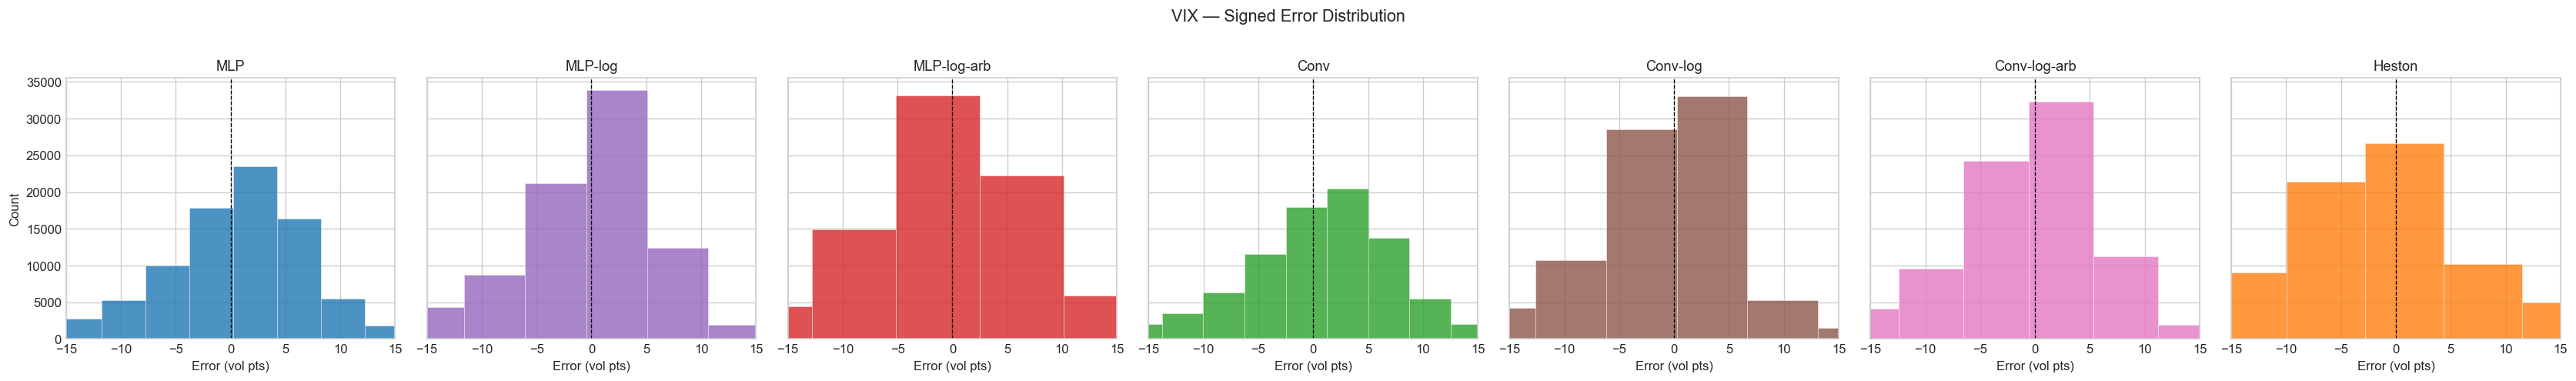

In [4]:
fig, axes = plt.subplots(1, len(MODEL_NAMES), figsize=(4*len(MODEL_NAMES), 4), sharey=True)
if len(MODEL_NAMES) == 1: axes = [axes]
for ax, name in zip(axes, MODEL_NAMES):
    e = errors[name] * 100
    ax.hist(e, bins=80, color=COLOURS[name], alpha=0.8, edgecolor="white", linewidth=0.3)
    ax.axvline(0, color="k", ls="--", lw=0.8)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Error (vol pts)")
    ax.set_xlim(-15, 15)
axes[0].set_ylabel("Count")
fig.suptitle(f"{TICKER} — Signed Error Distribution", fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(OUT / "plots" / "error_histograms.png", bbox_inches="tight", dpi=150)
plt.show()

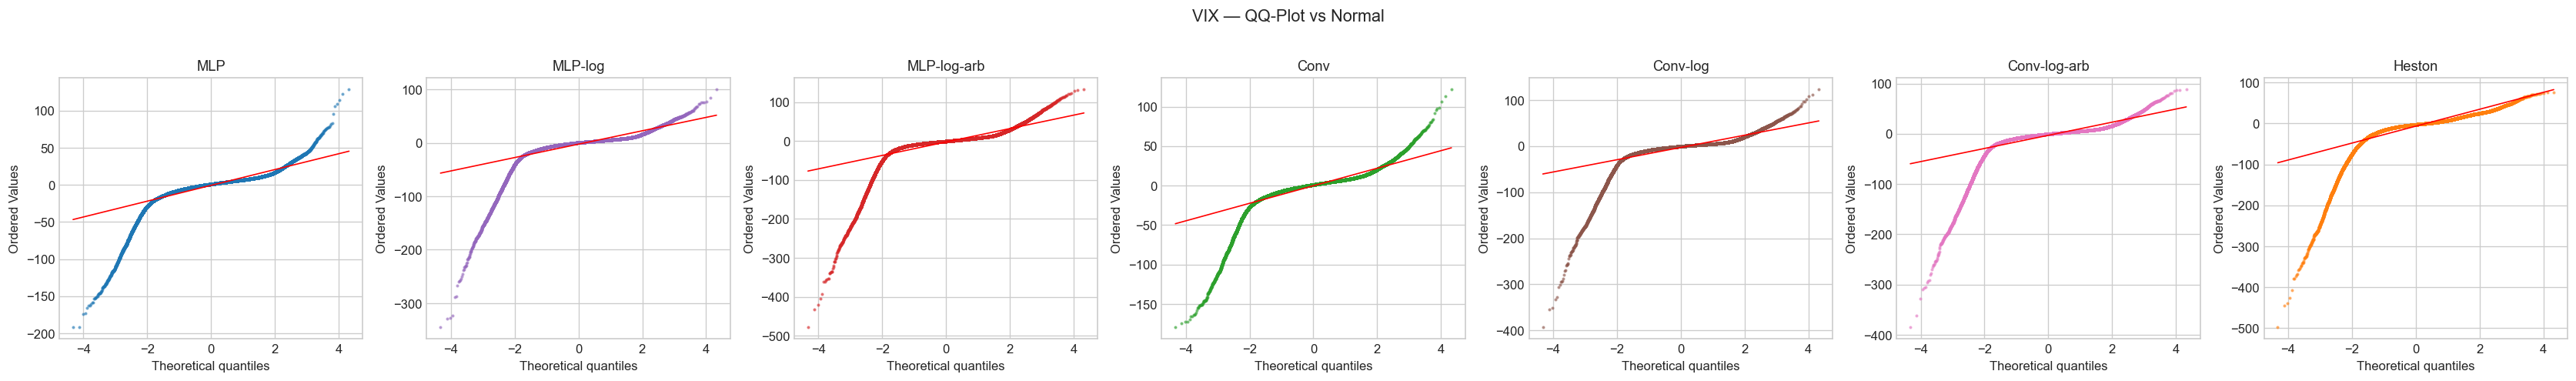

In [5]:
fig, axes = plt.subplots(1, len(MODEL_NAMES), figsize=(4*len(MODEL_NAMES), 4))
if len(MODEL_NAMES) == 1: axes = [axes]
for ax, name in zip(axes, MODEL_NAMES):
    e = errors[name] * 100
    stats.probplot(e, dist="norm", plot=ax)
    ax.set_title(name, fontsize=11)
    ax.get_lines()[0].set(color=COLOURS[name], markersize=1.5, alpha=0.5)
    ax.get_lines()[1].set(color="red", lw=1)
fig.suptitle(f"{TICKER} — QQ-Plot vs Normal", fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(OUT / "plots" / "error_qq_plots.png", bbox_inches="tight", dpi=150)
plt.show()

In [6]:
percentiles = [50, 75, 90, 95, 99]
rows = []
for name in MODEL_NAMES:
    ae = abs_errors[name] * 100
    se = errors[name] * 100
    row = {"Model": name, "Mean": se.mean(), "Std": se.std(),
           "Skew": float(stats.skew(se)), "Kurt": float(stats.kurtosis(se))}
    for p in percentiles:
        row[f"P{p}"] = np.percentile(ae, p)
    row["Max"] = ae.max()
    rows.append(row)

err_table = pd.DataFrame(rows).set_index("Model")
err_table.to_csv(OUT / "tables" / "error_distribution_stats.csv")
print(f"{TICKER} — Error Distribution (vol points):")
display(err_table.round(3))

VIX — Error Distribution (vol points):


,Mean,Std,Skew,Kurt,P50,P75,P90,P95,P99,Max
Model,,,,,,,,,,
MLP,-0.733,12.542000,-3.482,29.569,4.543,8.099,14.310000,21.351999,52.973999,191.753998
MLP-log,-2.548,16.405001,-5.376,50.313,4.175,7.881,15.831000,24.823000,77.700996,344.753998
MLP-log-arb,-2.471,22.712000,-5.246,51.646,5.483,10.407,20.893999,34.388000,104.195999,478.015015
Conv,-0.181,12.913000,-3.233,28.362,4.811,8.637,15.180000,22.416000,53.541000,179.253998
Conv-log,-2.858,17.587000,-5.439,54.424,4.069,8.071,16.822001,26.733999,81.915001,392.838989
Conv-log-arb,-2.929,17.596001,-5.787,56.246,4.278,8.057,15.681000,24.920000,82.294998,384.768005
Heston,-6.614,25.893999,-4.748,39.048,6.832,15.002,27.700001,43.979000,117.612999,497.622986


## §2  Signed Bias (Mean-Error Heatmaps)

C:\Users\Admin\AppData\Local\Temp\ipykernel_32504\2270130649.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


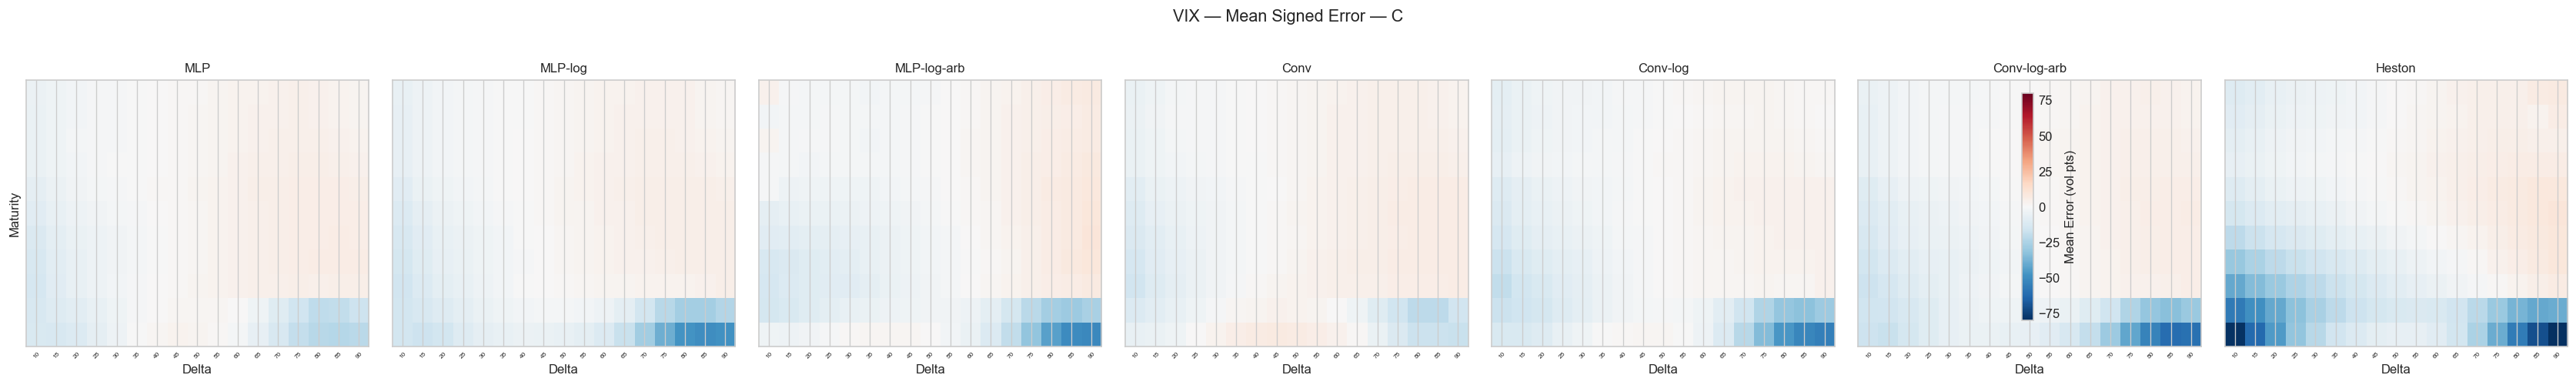

C:\Users\Admin\AppData\Local\Temp\ipykernel_32504\2270130649.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


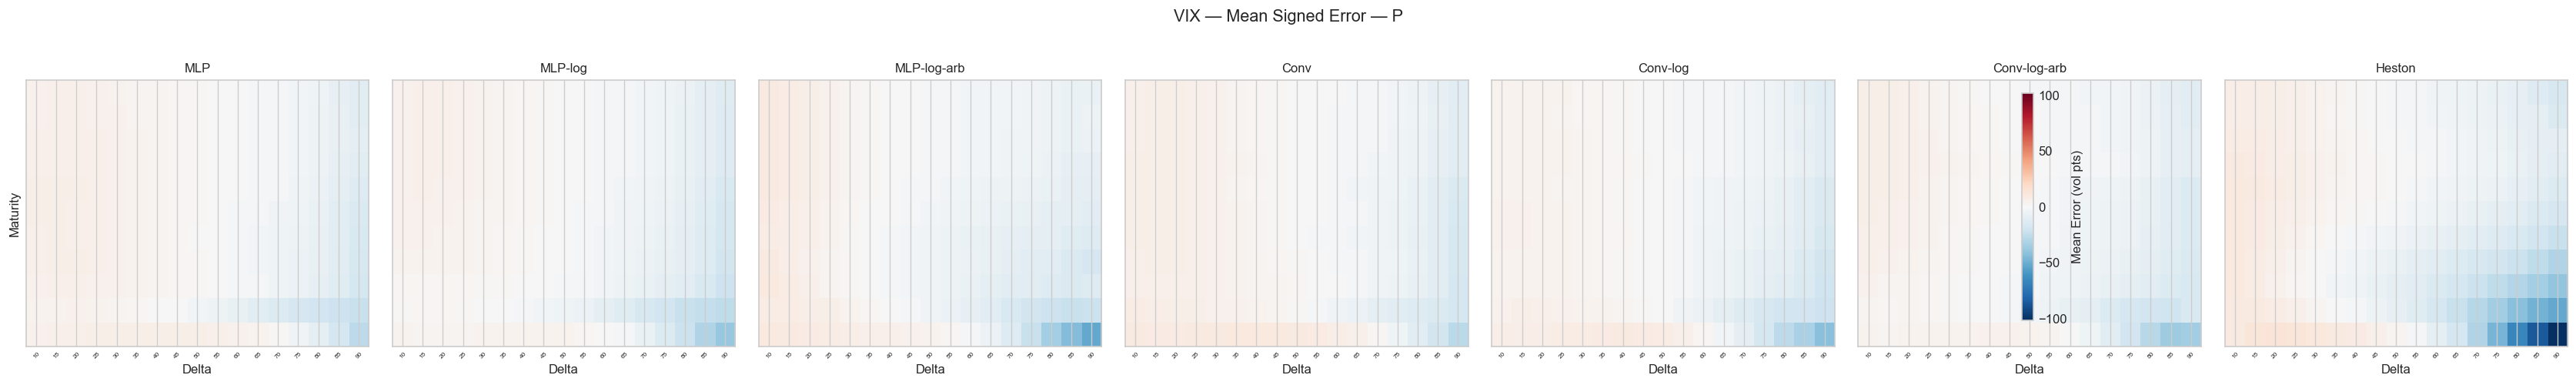

In [7]:
delta_labels = [f"{d:.0f}" for d in delta_grid * 100]
mat_labels = [f"{d:.0f}d" for d in days_grid]

for ch_idx, ch_name in enumerate(cp_labels):
    fig, axes = plt.subplots(1, len(MODEL_NAMES), figsize=(4*len(MODEL_NAMES), 4), sharey=True)
    if len(MODEL_NAMES) == 1: axes = [axes]
    vmax = 0
    mean_errs = {}
    for name in MODEL_NAMES:
        err_grid = models[name][:, ch_idx, :, :] - market[:, ch_idx, :, :]
        cell_valid = valid_mask[:, ch_idx, :, :]
        with np.errstate(invalid="ignore"):
            me = np.where(cell_valid, err_grid, np.nan)
            mean_errs[name] = np.nanmean(me, axis=0) * 100
        vmax = max(vmax, np.nanmax(np.abs(mean_errs[name])))

    for ax, name in zip(axes, MODEL_NAMES):
        im = ax.imshow(mean_errs[name], cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                       aspect="auto", origin="lower")
        ax.set_title(name, fontsize=10)
        ax.set_xticks(range(n_del))
        ax.set_xticklabels(delta_labels, fontsize=5, rotation=45)
        ax.set_xlabel("Delta")
        if ax is axes[0]:
            ax.set_yticks(range(n_mat))
            ax.set_yticklabels(mat_labels, fontsize=7)
            ax.set_ylabel("Maturity")
        else:
            ax.set_yticks([])

    fig.colorbar(im, ax=axes, shrink=0.8, label="Mean Error (vol pts)")
    fig.suptitle(f"{TICKER} — Mean Signed Error — {ch_name}", fontsize=13, y=1.03)
    fig.tight_layout()
    fig.savefig(OUT / "plots" / f"bias_heatmap_{ch_name}.png", bbox_inches="tight", dpi=150)
    plt.show()

## §3  MAPE / Relative Error

C:\Users\Admin\AppData\Local\Temp\ipykernel_32504\1274972120.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


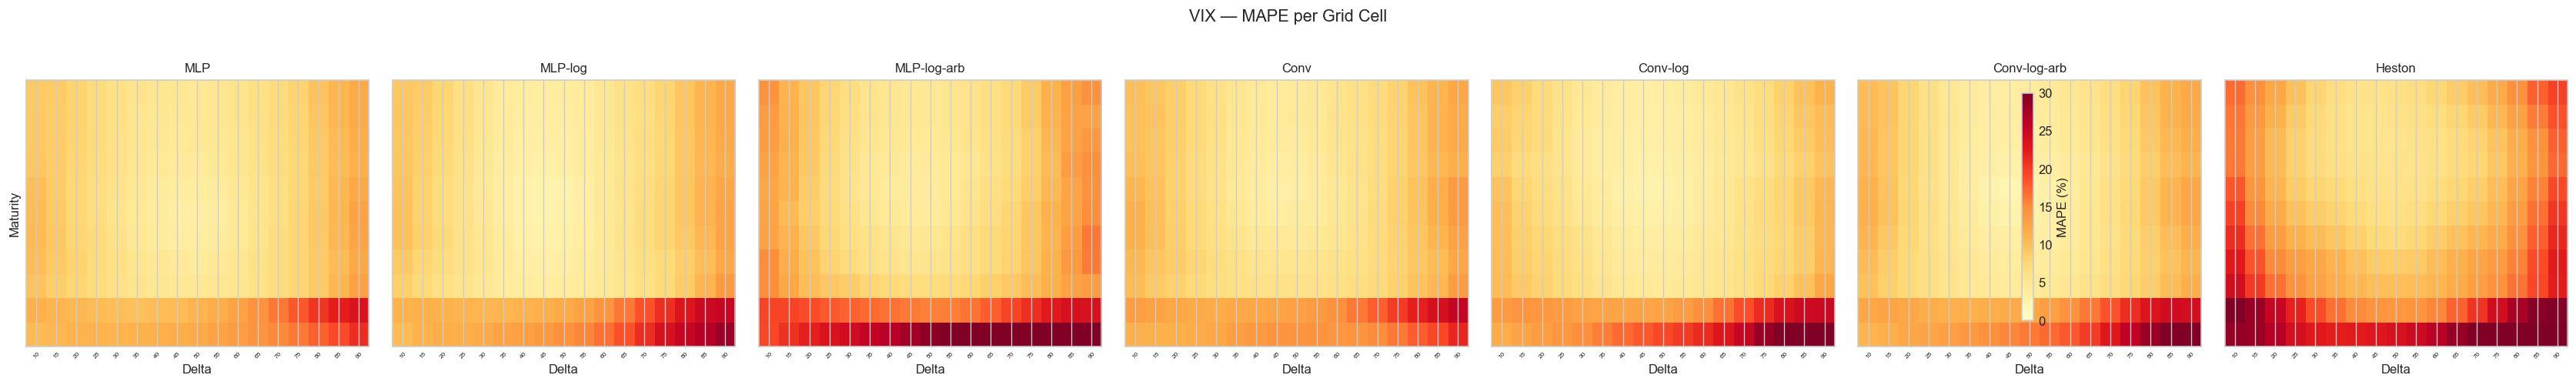

In [8]:
def mape_grid(model_surf, market_surf, vmask):
    with np.errstate(divide="ignore", invalid="ignore"):
        pct = np.abs(model_surf - market_surf) / np.abs(market_surf) * 100
        pct = np.where(vmask, pct, np.nan)
    return np.nanmean(pct, axis=0)

fig, axes = plt.subplots(1, len(MODEL_NAMES), figsize=(4*len(MODEL_NAMES), 4), sharey=True)
if len(MODEL_NAMES) == 1: axes = [axes]
vmax_mape = 0
mape_grids = {}
for name in MODEL_NAMES:
    mg = mape_grid(models[name], market, valid_mask)
    mape_grids[name] = mg.mean(axis=0)
    vmax_mape = max(vmax_mape, np.nanmax(mape_grids[name]))

for ax, name in zip(axes, MODEL_NAMES):
    im = ax.imshow(mape_grids[name], cmap="YlOrRd", vmin=0, vmax=min(vmax_mape, 30),
                   aspect="auto", origin="lower")
    ax.set_title(name, fontsize=10)
    ax.set_xticks(range(n_del))
    ax.set_xticklabels(delta_labels, fontsize=5, rotation=45)
    ax.set_xlabel("Delta")
    if ax is axes[0]:
        ax.set_yticks(range(n_mat))
        ax.set_yticklabels(mat_labels, fontsize=7)
        ax.set_ylabel("Maturity")
    else:
        ax.set_yticks([])

fig.colorbar(im, ax=axes, shrink=0.8, label="MAPE (%)")
fig.suptitle(f"{TICKER} — MAPE per Grid Cell", fontsize=13, y=1.03)
fig.tight_layout()
fig.savefig(OUT / "plots" / "mape_heatmaps.png", bbox_inches="tight", dpi=150)
plt.show()

In [9]:
rows = []
for name in MODEL_NAMES:
    m_flat = market[valid_mask]
    s_flat = models[name][valid_mask]
    pct_all = np.abs(s_flat - m_flat) / np.abs(m_flat) * 100
    high_mask = m_flat > 0.20
    low_mask = m_flat <= 0.20
    rows.append({
        "Model": name,
        "MAPE (all)": pct_all.mean(),
        "MAPE (IV>20%)": pct_all[high_mask].mean() if high_mask.sum() > 0 else np.nan,
        "MAPE (IV≤20%)": pct_all[low_mask].mean() if low_mask.sum() > 0 else np.nan,
        "N (IV>20%)": int(high_mask.sum()),
        "N (IV≤20%)": int(low_mask.sum()),
    })

mape_table = pd.DataFrame(rows).set_index("Model")
mape_table.to_csv(OUT / "tables" / "mape_summary.csv")
display(mape_table.round(2))

,MAPE (all),MAPE (IV>20%),MAPE (IV≤20%),N (IV>20%),N (IV≤20%)
Model,,,,,
MLP,8.17,8.16,194.119995,90777,5
MLP-log,8.15,8.13,326.049988,90777,5
MLP-log-arb,11.39,11.36,669.799988,90777,5
Conv,8.69,8.67,228.250000,90777,5
Conv-log,8.32,8.29,440.540009,90777,5
Conv-log-arb,8.40,8.37,435.820007,90777,5
Heston,13.71,13.69,310.529999,90777,5


## §4  KS Test Per-Cell

In [10]:
ks_pvals = {}
ks_stats_arr = {}

for name in MODEL_NAMES:
    pvals = np.full((n_chan, n_mat, n_del), np.nan)
    kstats = np.full((n_chan, n_mat, n_del), np.nan)
    surf = models[name]
    for c in range(n_chan):
        for h in range(n_mat):
            for w in range(n_del):
                vmask_cell = valid_mask[:, c, h, w]
                if vmask_cell.sum() < 10:
                    continue
                m_vals = market[vmask_cell, c, h, w]
                s_vals = surf[vmask_cell, c, h, w]
                stat, p = ks_2samp(m_vals, s_vals)
                kstats[c, h, w] = stat
                pvals[c, h, w] = p
    ks_pvals[name] = pvals
    ks_stats_arr[name] = kstats
    reject_pct = 100 * np.nansum(pvals < 0.05) / np.sum(~np.isnan(pvals))
    print(f"{name:<14} reject (p<0.05): {np.nansum(pvals < 0.05):3.0f} / "
          f"{np.sum(~np.isnan(pvals))} ({reject_pct:.1f}%)")

MLP            reject (p<0.05): 320 / 374 (85.6%)
MLP-log        reject (p<0.05): 345 / 374 (92.2%)


MLP-log-arb    reject (p<0.05): 373 / 374 (99.7%)
Conv           reject (p<0.05): 349 / 374 (93.3%)


Conv-log       reject (p<0.05): 350 / 374 (93.6%)
Conv-log-arb   reject (p<0.05): 354 / 374 (94.7%)


Heston         reject (p<0.05): 371 / 374 (99.2%)


C:\Users\Admin\AppData\Local\Temp\ipykernel_32504\1449277894.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


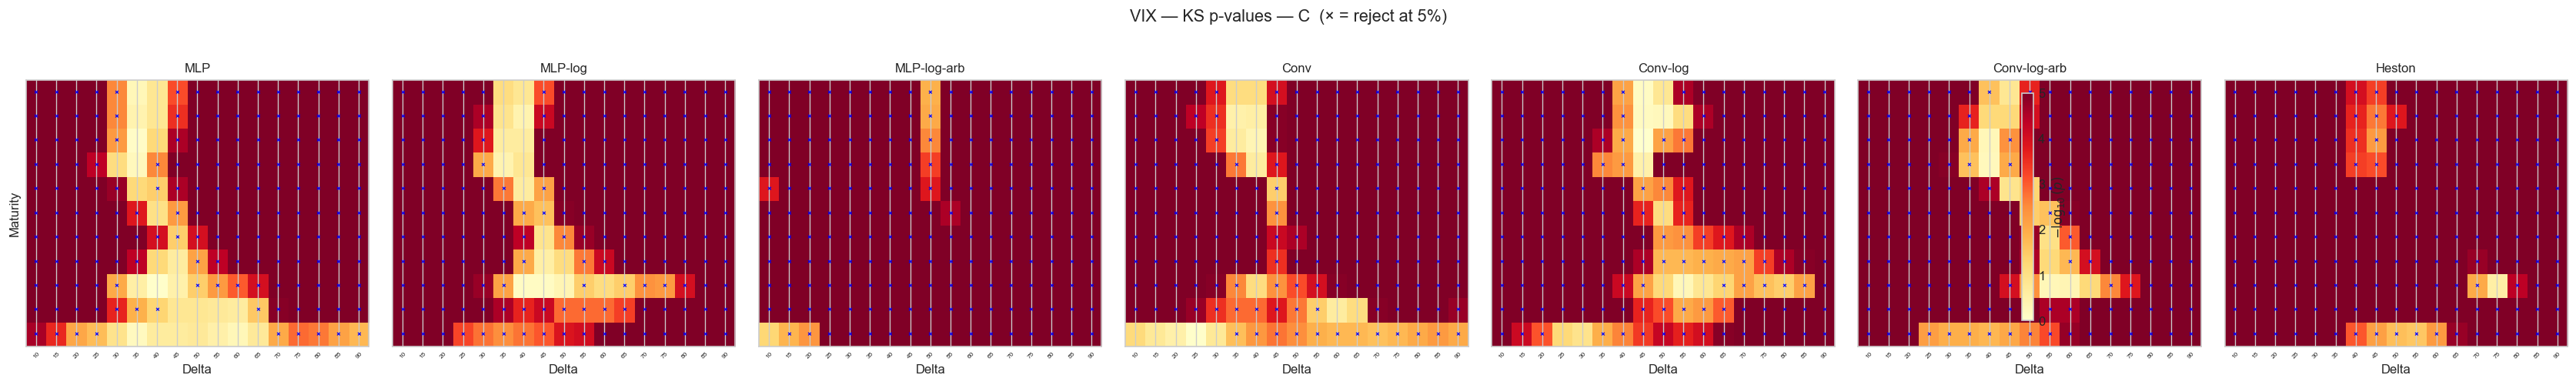

C:\Users\Admin\AppData\Local\Temp\ipykernel_32504\1449277894.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


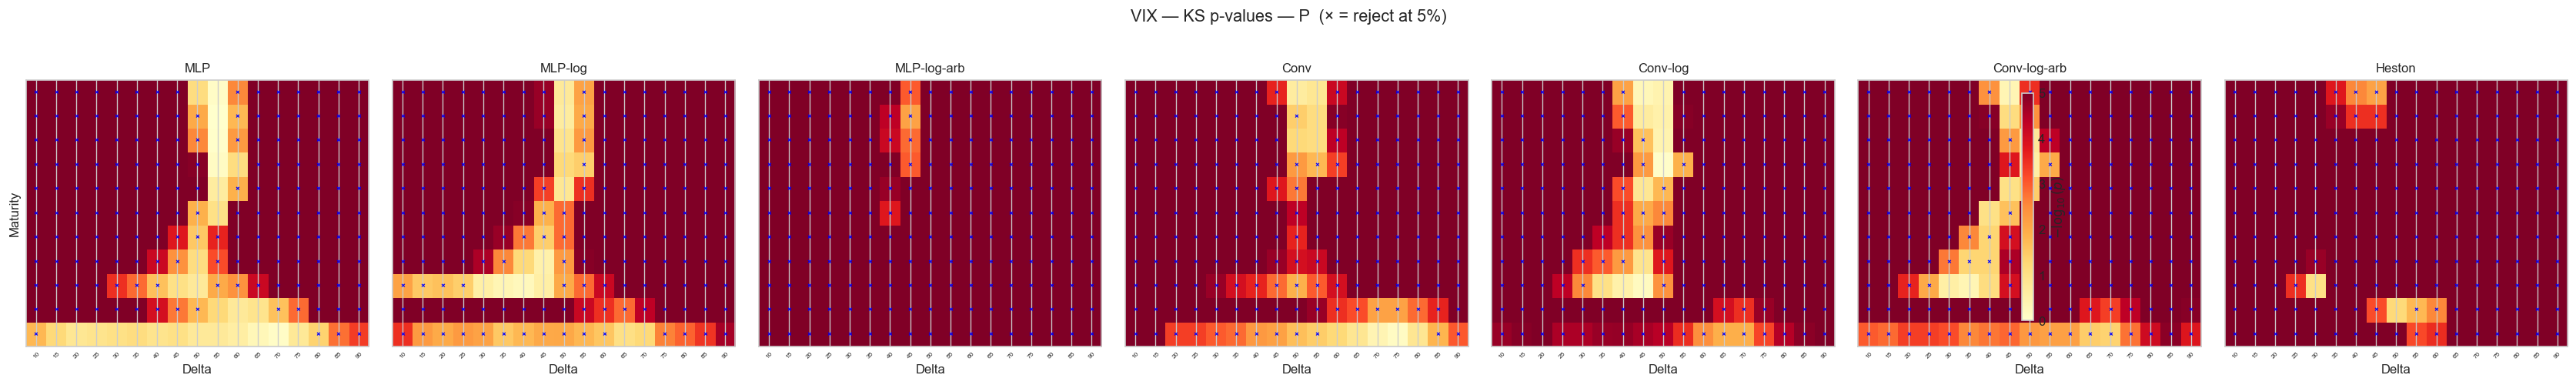

,Cells tested,Reject (p<0.05),Reject (p<0.01),Reject %,Median p,Mean KS stat
Model,,,,,,
MLP,374,320,303,85.5615,0.0,0.3641
MLP-log,374,345,332,92.2460,0.0,0.3827
MLP-log-arb,374,373,371,99.7326,0.0,0.5823
Conv,374,349,335,93.3155,0.0,0.3825
Conv-log,374,350,338,93.5829,0.0,0.3712
Conv-log-arb,374,354,338,94.6524,0.0,0.3985
Heston,374,371,368,99.1979,0.0,0.4601


In [11]:
for ch_idx, ch_name in enumerate(cp_labels):
    fig, axes = plt.subplots(1, len(MODEL_NAMES), figsize=(4*len(MODEL_NAMES), 4), sharey=True)
    if len(MODEL_NAMES) == 1: axes = [axes]
    for ax, name in zip(axes, MODEL_NAMES):
        pv = ks_pvals[name][ch_idx]
        log_p = -np.log10(np.clip(pv, 1e-20, 1.0))
        im = ax.imshow(log_p, cmap="YlOrRd", vmin=0, vmax=5, aspect="auto", origin="lower")
        for h in range(n_mat):
            for w in range(n_del):
                if pv[h, w] < 0.05:
                    ax.text(w, h, "×", ha="center", va="center", fontsize=6, color="blue", fontweight="bold")
        ax.set_title(name, fontsize=10)
        ax.set_xticks(range(n_del))
        ax.set_xticklabels(delta_labels, fontsize=5, rotation=45)
        ax.set_xlabel("Delta")
        if ax is axes[0]:
            ax.set_yticks(range(n_mat))
            ax.set_yticklabels(mat_labels, fontsize=7)
            ax.set_ylabel("Maturity")
        else:
            ax.set_yticks([])

    fig.colorbar(im, ax=axes, shrink=0.8, label="$-\\log_{10}(p)$")
    fig.suptitle(f"{TICKER} — KS p-values — {ch_name}  (× = reject at 5%)", fontsize=13, y=1.03)
    fig.tight_layout()
    fig.savefig(OUT / "plots" / f"ks_pvalues_{ch_name}.png", bbox_inches="tight", dpi=150)
    plt.show()

ks_summary = []
for name in MODEL_NAMES:
    pv = ks_pvals[name]
    valid_cells = np.sum(~np.isnan(pv))
    ks_summary.append({
        "Model": name,
        "Cells tested": int(valid_cells),
        "Reject (p<0.05)": int(np.nansum(pv < 0.05)),
        "Reject (p<0.01)": int(np.nansum(pv < 0.01)),
        "Reject %": 100 * np.nansum(pv < 0.05) / valid_cells,
        "Median p": np.nanmedian(pv),
        "Mean KS stat": np.nanmean(ks_stats_arr[name]),
    })
ks_df = pd.DataFrame(ks_summary).set_index("Model")
ks_df.to_csv(OUT / "tables" / "ks_test_summary.csv")
display(ks_df.round(4))

## §5  Diebold-Mariano Pairwise Significance

DM t-statistics (positive → row model is worse):


,MLP,MLP-log,MLP-log-arb,Conv,Conv-log,Conv-log-arb,Heston
MLP,0.000,-9.647,-10.938,-3.056,-10.269,-10.164,-16.691
MLP-log,9.647,0.000,-9.434,9.394,-5.649,-6.011,-16.670
MLP-log-arb,10.938,9.434,0.000,10.827,8.190,8.862,-8.617
Conv,3.056,-9.394,-10.827,0.000,-10.116,-9.970,-16.612
Conv-log,10.269,5.649,-8.190,10.116,0.000,-0.134,-16.778
Conv-log-arb,10.164,6.011,-8.862,9.970,0.134,0.000,-17.317
Heston,16.691,16.670,8.617,16.612,16.778,17.317,0.000



DM p-values (two-sided):


,MLP,MLP-log,MLP-log-arb,Conv,Conv-log,Conv-log-arb,Heston
MLP,1.0000,0.0,0.0,0.0022,0.0000,0.0000,0.0
MLP-log,0.0000,1.0,0.0,0.0000,0.0000,0.0000,0.0
MLP-log-arb,0.0000,0.0,1.0,0.0000,0.0000,0.0000,0.0
Conv,0.0022,0.0,0.0,1.0000,0.0000,0.0000,0.0
Conv-log,0.0000,0.0,0.0,0.0000,1.0000,0.8931,0.0
Conv-log-arb,0.0000,0.0,0.0,0.0000,0.8931,1.0000,0.0
Heston,0.0000,0.0,0.0,0.0000,0.0000,0.0000,1.0


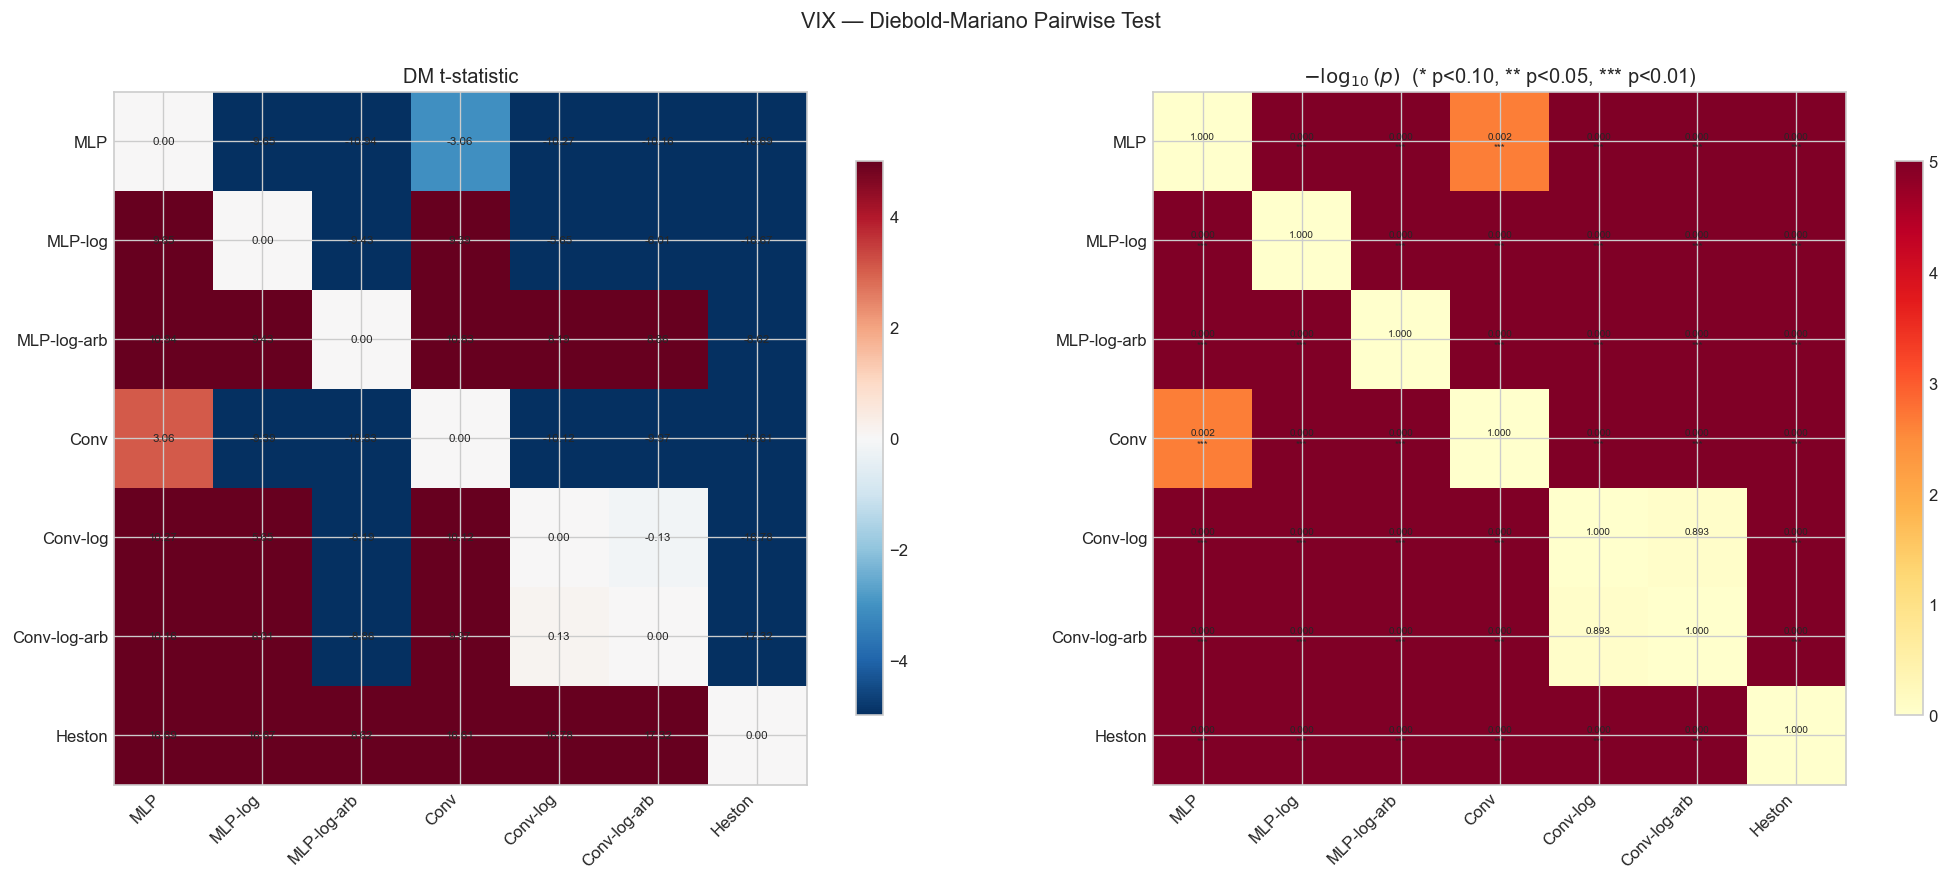

In [12]:
def diebold_mariano(e1, e2):
    d = e1**2 - e2**2
    d_bar = d.mean()
    n = len(d)
    gamma_0 = np.var(d, ddof=1)
    se = np.sqrt(gamma_0 / n)
    if se < 1e-15:
        return 0.0, 1.0
    t = d_bar / se
    p = 2 * (1 - stats.norm.cdf(np.abs(t)))
    return t, p

date_mse = {}
for name in MODEL_NAMES:
    err = models[name] - market
    se_grid = np.where(valid_mask, err**2, np.nan)
    date_mse[name] = np.nanmean(se_grid.reshape(N, -1), axis=1)

n_models = len(MODEL_NAMES)
dm_tstat = np.zeros((n_models, n_models))
dm_pval = np.ones((n_models, n_models))

for i in range(n_models):
    for j in range(n_models):
        if i == j:
            continue
        e1 = np.sqrt(date_mse[MODEL_NAMES[i]])
        e2 = np.sqrt(date_mse[MODEL_NAMES[j]])
        t, p = diebold_mariano(e1, e2)
        dm_tstat[i, j] = t
        dm_pval[i, j] = p

dm_t_df = pd.DataFrame(dm_tstat, index=MODEL_NAMES, columns=MODEL_NAMES)
dm_p_df = pd.DataFrame(dm_pval, index=MODEL_NAMES, columns=MODEL_NAMES)

print("DM t-statistics (positive → row model is worse):")
display(dm_t_df.round(3))
print("\nDM p-values (two-sided):")
display(dm_p_df.round(4))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
im1 = ax1.imshow(dm_tstat, cmap="RdBu_r", vmin=-5, vmax=5)
ax1.set_xticks(range(n_models)); ax1.set_xticklabels(MODEL_NAMES, rotation=45, ha="right")
ax1.set_yticks(range(n_models)); ax1.set_yticklabels(MODEL_NAMES)
for i in range(n_models):
    for j in range(n_models):
        ax1.text(j, i, f"{dm_tstat[i,j]:.2f}", ha="center", va="center", fontsize=7)
ax1.set_title("DM t-statistic")
fig.colorbar(im1, ax=ax1, shrink=0.8)

im2 = ax2.imshow(-np.log10(np.clip(dm_pval, 1e-20, 1)), cmap="YlOrRd", vmin=0, vmax=5)
ax2.set_xticks(range(n_models)); ax2.set_xticklabels(MODEL_NAMES, rotation=45, ha="right")
ax2.set_yticks(range(n_models)); ax2.set_yticklabels(MODEL_NAMES)
for i in range(n_models):
    for j in range(n_models):
        marker = ""
        if dm_pval[i,j] < 0.01: marker = "***"
        elif dm_pval[i,j] < 0.05: marker = "**"
        elif dm_pval[i,j] < 0.10: marker = "*"
        ax2.text(j, i, f"{dm_pval[i,j]:.3f}\n{marker}", ha="center", va="center", fontsize=6)
ax2.set_title("$-\\log_{10}(p)$  (* p<0.10, ** p<0.05, *** p<0.01)")
fig.colorbar(im2, ax=ax2, shrink=0.8)

fig.suptitle(f"{TICKER} — Diebold-Mariano Pairwise Test", fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(OUT / "plots" / "diebold_mariano.png", bbox_inches="tight", dpi=150)
plt.show()

dm_t_df.to_csv(OUT / "tables" / "dm_tstat.csv")
dm_p_df.to_csv(OUT / "tables" / "dm_pval.csv")

## §6  Backtesting (Exceedance + Kupiec POF + Traffic Light)

In [13]:
def kupiec_pof(T, N_exc, alpha):
    p_hat = N_exc / T
    if N_exc == 0:
        lr = -2 * T * np.log(1 - alpha)
        return lr, 1 - chi2.cdf(lr, 1)
    if N_exc == T:
        lr = -2 * T * np.log(alpha)
        return lr, 1 - chi2.cdf(lr, 1)
    lr = -2 * (N_exc * np.log(alpha / p_hat) + (T - N_exc) * np.log((1 - alpha) / (1 - p_hat)))
    return lr, 1 - chi2.cdf(lr, 1)

def traffic_light(N_exc, T, alpha):
    expected = T * alpha
    std = np.sqrt(T * alpha * (1 - alpha))
    if N_exc <= expected + std:
        return "Green"
    elif N_exc <= expected + 2 * std:
        return "Yellow"
    else:
        return "Red"

alphas = [0.01, 0.025, 0.05]
qt_rows = []
for name in MODEL_NAMES:
    date_mae = np.array([
        np.nanmean(np.abs(models[name][t][valid_mask[t]] - market[t][valid_mask[t]]))
        for t in range(N)
    ])
    for alpha in alphas:
        thr = np.quantile(date_mae, 1 - alpha)
        N_exc = (date_mae > thr).sum()
        expected = N * alpha
        lr, pval = kupiec_pof(N, N_exc, alpha)
        tl = traffic_light(N_exc, N, alpha)
        qt_rows.append({
            "Model": name, "α": f"{alpha:.1%}",
            "Threshold (vp)": thr * 100,
            "Exceedances": N_exc, "Expected": expected,
            "Kupiec LR": lr, "Kupiec p": pval,
            "Traffic Light": tl,
        })

qt_df = pd.DataFrame(qt_rows)
display(qt_df.set_index(["Model", "α"]))
qt_df.to_csv(OUT / "tables" / "backtest_quantile.csv", index=False)

Threshold (vp)  Exceedances  Expected  Kupiec LR  Kupiec p  \
Model        α                                                                  
MLP          1.0%       14.160596            3      2.44   0.120985  0.727969   
             2.5%       12.840583            7      6.10   0.130108  0.718320   
             5.0%       10.843960           13     12.20   0.054113  0.816055   
MLP-log      1.0%       14.352739            3      2.44   0.120985  0.727969   
             2.5%       13.292090            7      6.10   0.130108  0.718320   
             5.0%       11.850673           13     12.20   0.054113  0.816055   
MLP-log-arb  1.0%       26.431379            3      2.44   0.120985  0.727969   
             2.5%       22.175493            7      6.10   0.130108  0.718320   
             5.0%       17.259430           13     12.20   0.054113  0.816055   
Conv         1.0%       12.941135            3      2.44   0.120985  0.727969   
             2.5%       12.245675            7      6.10   0.130108  0.718320   
             5.0%       11.062143           13     12.20   0.054113  0.816055   
Conv-log     1.0%       15.755655            3      2.44   0.120985  0.727969   
             2.5%       14.485293            7      6.10   0.130108  0.718320   
             5.0%       13.089752           13     12.20   0.054113  0.816055   
Conv-log-arb 1.0%       16.082319            3      2.44   0.120985  0.727969   
             2.5%       14.392879            7      6.10   0.130108  0.718320   
             5.0%       13.171688           13     12.20   0.054113  0.816055   
Heston       1.0%       26.525616            3      2.44   0.120985  0.727969   
             2.5%       25.260397            7      6.10   0.130108  0.718320   
             5.0%       23.356691           13     12.20   0.054113  0.816055   

                  Traffic Light  
Model        α                   
MLP          1.0%         Green  
             2.5%         Green  
             5.0%         Green  
MLP-log      1.0%         Green  
             2.5%         Green  
             5.0%         Green  
MLP-log-arb  1.0%         Green  
             2.5%         Green  
             5.0%         Green  
Conv         1.0%         Green  
             2.5%         Green  
             5.0%         Green  
Conv-log     1.0%         Green  
             2.5%         Green  
             5.0%         Green  
Conv-log-arb 1.0%         Green  
             2.5%         Green  
             5.0%         Green  
Heston       1.0%         Green  
             2.5%         Green  
             5.0%         Green

Exceedances    Rate
Model        Threshold (vp)                     
MLP          2                       244  100.0%
             5                       213   87.3%
             10                       20    8.2%
MLP-log      2                       244  100.0%
             5                       228   93.4%
             10                       41   16.8%
MLP-log-arb  2                       244  100.0%
             5                       243   99.6%
             10                      107   43.9%
Conv         2                       244  100.0%
             5                       228   93.4%
             10                       25   10.2%
Conv-log     2                       244  100.0%
             5                       227   93.0%
             10                       45   18.4%
Conv-log-arb 2                       244  100.0%
             5                       227   93.0%
             10                       42   17.2%
Heston       2                       244  100.0%
             5                       244  100.0%
             10                      164   67.2%

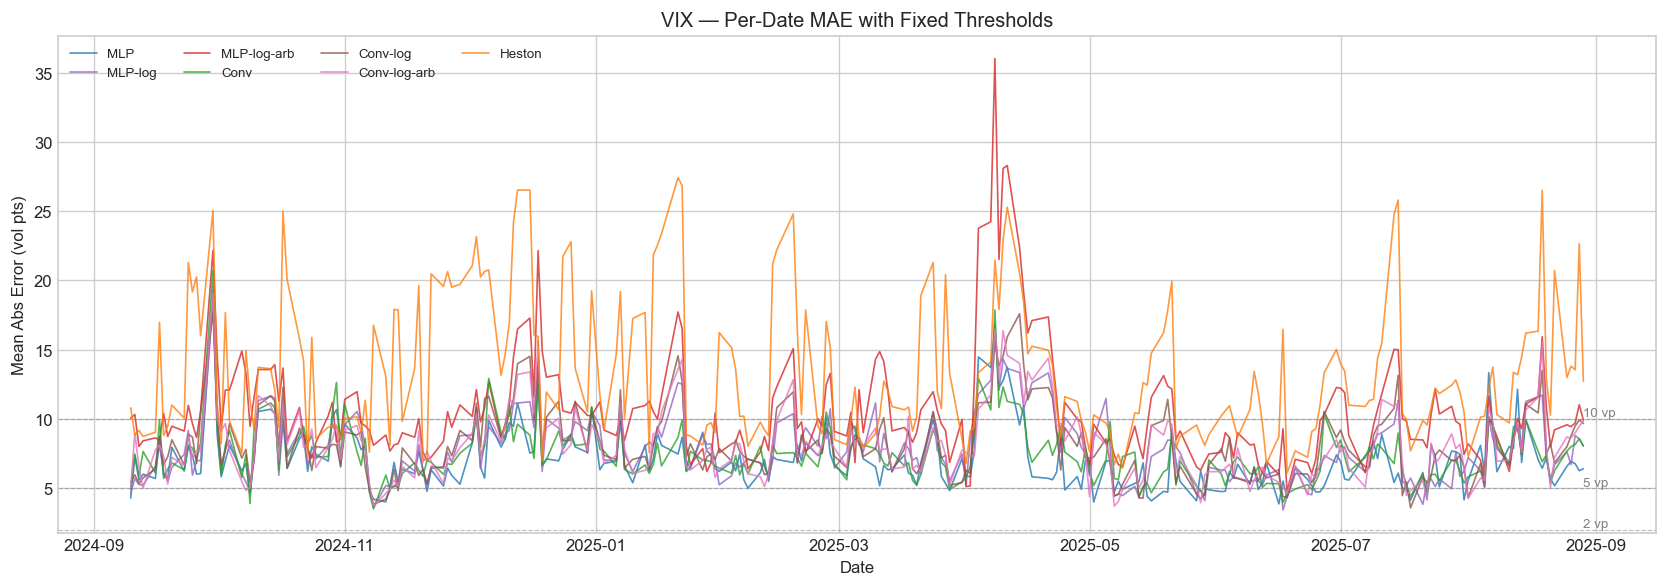

In [14]:
thresholds_vp = [2, 5, 10]
ft_rows = []
for name in MODEL_NAMES:
    date_mae = np.array([
        np.nanmean(np.abs(models[name][t][valid_mask[t]] - market[t][valid_mask[t]]))
        for t in range(N)
    ]) * 100
    for thr in thresholds_vp:
        N_exc = (date_mae > thr).sum()
        ft_rows.append({
            "Model": name, "Threshold (vp)": thr,
            "Exceedances": N_exc, "Rate": f"{N_exc/N:.1%}",
        })

ft_df = pd.DataFrame(ft_rows)
display(ft_df.set_index(["Model", "Threshold (vp)"]))
ft_df.to_csv(OUT / "tables" / "backtest_fixed_threshold.csv", index=False)

fig, ax = plt.subplots(figsize=(14, 5))
for name in MODEL_NAMES:
    date_mae = np.array([
        np.nanmean(np.abs(models[name][t][valid_mask[t]] - market[t][valid_mask[t]]))
        for t in range(N)
    ]) * 100
    ax.plot(aligned_dates, date_mae, color=COLOURS[name], label=name, alpha=0.8, lw=1)
for thr in thresholds_vp:
    ax.axhline(thr, color="grey", ls="--", lw=0.7, alpha=0.5)
    ax.text(aligned_dates.iloc[-1], thr + 0.2, f"{thr} vp", fontsize=8, color="grey")
ax.set_ylabel("Mean Abs Error (vol pts)")
ax.set_xlabel("Date")
ax.set_title(f"{TICKER} — Per-Date MAE with Fixed Thresholds")
ax.legend(fontsize=8, ncol=4, loc="upper left")
fig.tight_layout()
fig.savefig(OUT / "plots" / "backtest_timeseries.png", bbox_inches="tight", dpi=150)
plt.show()

## §7  Regime Conditioning

In [15]:
atm_delta_idx = np.argmin(np.abs(delta_grid - 0.50))
mid_mat_idx = np.argmin(np.abs(days_grid - 182))
print(f"ATM proxy: delta[{atm_delta_idx}]={delta_grid[atm_delta_idx]:.2f}, "
      f"maturity[{mid_mat_idx}]={days_grid[mid_mat_idx]:.0f}d")

atm_iv = market[:, 0, mid_mat_idx, atm_delta_idx]
print(f"ATM IV range: [{atm_iv.min()*100:.1f}%, {atm_iv.max()*100:.1f}%]")

t1, t2 = np.percentile(atm_iv, [33.3, 66.7])
regime_labels = np.where(atm_iv <= t1, "Low", np.where(atm_iv <= t2, "Mid", "High"))
print(f"Terciles: Low ≤ {t1*100:.1f}%, Mid ≤ {t2*100:.1f}%, High > {t2*100:.1f}%")
print(f"Counts: Low={np.sum(regime_labels=='Low')}, Mid={np.sum(regime_labels=='Mid')}, "
      f"High={np.sum(regime_labels=='High')}")

ATM proxy: delta[8]=0.50, maturity[6]=182d
ATM IV range: [62.6%, 99.4%]
Terciles: Low ≤ 66.5%, Mid ≤ 68.8%, High > 68.8%
Counts: Low=81, Mid=82, High=81


MAE (vp)                  RMSE (vp)                      
Regime           High     Low     Mid       High        Low        Mid
Model                                                                 
Conv            8.368   6.850   7.166  14.480000  12.380000  11.751000
Conv-log        9.127   7.362   7.961  19.806000  16.371000  17.118999
Conv-log-arb    9.059   7.359   7.848  19.819000  16.681999  16.868999
Heston         13.424  13.302  13.294  28.316000  26.111000  25.700001
MLP             8.055   6.545   6.722  14.386000  11.681000  11.441000
MLP-log         8.900   7.010   7.601  18.968000  14.934000  15.657000
MLP-log-arb    12.688   9.445   9.384  27.219999  20.711000  19.982000

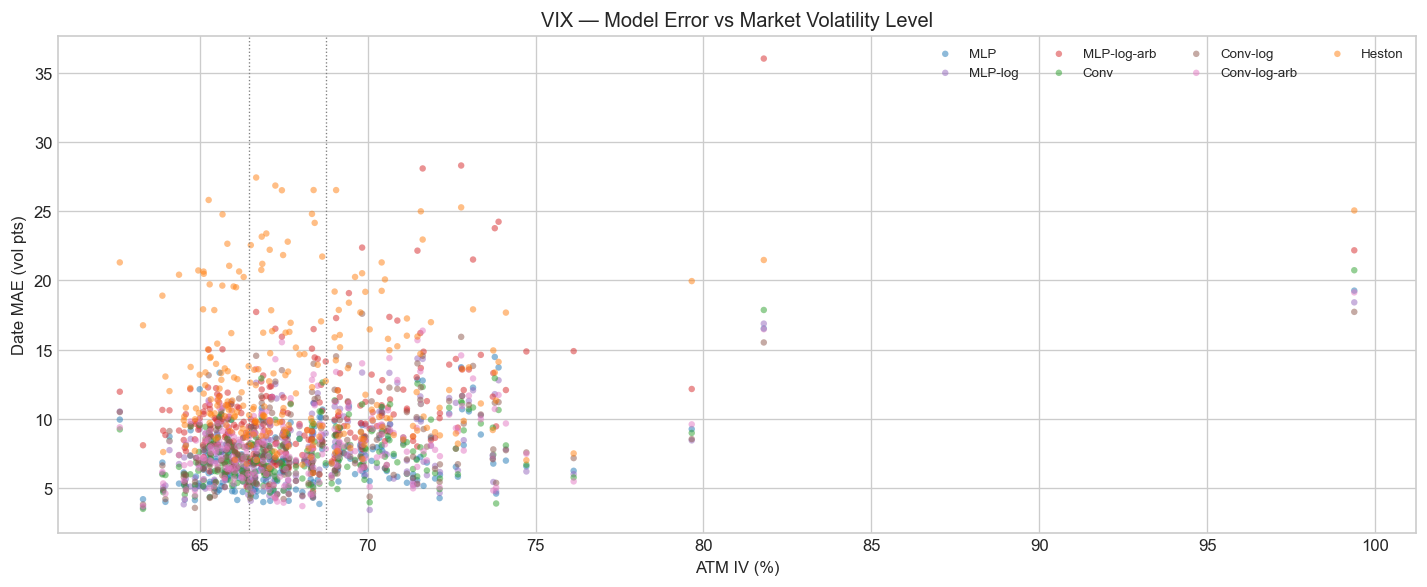

In [16]:
regime_rows = []
for name in MODEL_NAMES:
    for regime in ["Low", "Mid", "High"]:
        idx = np.where(regime_labels == regime)[0]
        surf_sub = models[name][idx]
        mkt_sub = market[idx]
        vm_sub = valid_mask[idx]
        ae = np.abs(surf_sub[vm_sub] - mkt_sub[vm_sub])
        regime_rows.append({
            "Model": name, "Regime": regime,
            "MAE (vp)": ae.mean() * 100,
            "RMSE (vp)": np.sqrt((ae**2).mean()) * 100,
            "P95 (vp)": np.percentile(ae, 95) * 100,
            "N dates": len(idx),
        })

regime_df = pd.DataFrame(regime_rows)
regime_pivot = regime_df.pivot_table(
    index="Model", columns="Regime",
    values=["MAE (vp)", "RMSE (vp)"],
)[["MAE (vp)", "RMSE (vp)"]].round(3)
regime_pivot.to_csv(OUT / "tables" / "regime_mae.csv")
display(regime_pivot)

fig, ax = plt.subplots(figsize=(12, 5))
for name in MODEL_NAMES:
    date_mae = np.array([
        np.nanmean(np.abs(models[name][t][valid_mask[t]] - market[t][valid_mask[t]]))
        for t in range(N)
    ]) * 100
    ax.scatter(atm_iv * 100, date_mae, color=COLOURS[name], label=name, alpha=0.5, s=15, edgecolors="none")
ax.set_xlabel("ATM IV (%)")
ax.set_ylabel("Date MAE (vol pts)")
ax.set_title(f"{TICKER} — Model Error vs Market Volatility Level")
ax.axvline(t1 * 100, color="grey", ls=":", lw=0.8)
ax.axvline(t2 * 100, color="grey", ls=":", lw=0.8)
ax.legend(fontsize=8, ncol=4)
fig.tight_layout()
fig.savefig(OUT / "plots" / "regime_scatter.png", bbox_inches="tight", dpi=150)
plt.show()

## §8  Arbitrage Violation Counting

In [17]:
def count_calendar_violations(surfaces, days, valid=None):
    T = np.array(days) / 365.0
    T = T[np.newaxis, np.newaxis, :, np.newaxis]
    total_var = surfaces**2 * T
    diff = np.diff(total_var, axis=2)
    if valid is not None:
        v1 = valid[:, :, :-1, :]
        v2 = valid[:, :, 1:, :]
        vmask = v1 & v2
        violations = (diff[vmask] < -1e-8)
    else:
        violations = (diff < -1e-8)
    return int(violations.sum()), violations

def count_butterfly_violations(surfaces, valid=None):
    d2 = np.diff(surfaces, n=2, axis=3)
    if valid is not None:
        v1 = valid[:, :, :, :-2]
        v2 = valid[:, :, :, 1:-1]
        v3 = valid[:, :, :, 2:]
        vmask = v1 & v2 & v3
        violations = (d2[vmask] < -1e-8)
    else:
        violations = (d2 < -1e-8)
    return int(violations.sum()), violations

arb_rows = []
all_surfs = {**models, "Market": market}
for name, surf in all_surfs.items():
    vm = valid_mask if name != "Market" else np.ones_like(valid_mask)
    cal_count, _ = count_calendar_violations(surf, days_grid, vm)
    but_count, _ = count_butterfly_violations(surf, vm)
    cal_total = int(vm[:, :, :-1, :].sum()) if name != "Market" else N * n_chan * (n_mat - 1) * n_del
    but_total = int(vm[:, :, :, :-2].sum()) if name != "Market" else N * n_chan * n_mat * (n_del - 2)
    arb_rows.append({
        "Surface": name,
        "Calendar violations": cal_count,
        "Calendar total": cal_total,
        "Calendar %": 100 * cal_count / max(cal_total, 1),
        "Butterfly violations": but_count,
        "Butterfly total": but_total,
        "Butterfly %": 100 * but_count / max(but_total, 1),
    })

arb_df = pd.DataFrame(arb_rows).set_index("Surface")
arb_df.to_csv(OUT / "tables" / "arbitrage_violations.csv")
display(arb_df.round(3))

,Calendar violations,Calendar total,Calendar %,Butterfly violations,Butterfly total,Butterfly %
Surface,,,,,,
MLP,1442,82726,1.743,34097,80432,42.392
MLP-log,612,82726,0.740,35764,80432,44.465
MLP-log-arb,100,82726,0.121,4764,80432,5.923
Conv,1421,82726,1.718,32970,80432,40.991
Conv-log,401,82726,0.485,32514,80432,40.424
Conv-log-arb,167,82726,0.202,2792,80432,3.471
Heston,121,82726,0.146,17933,80432,22.296
Market,2555,82960,3.080,21086,80520,26.187


## §9  Surface Smoothness

VIX — Surface Smoothness (lower = smoother):


,Laplacian |∇²σ|,Total Variation
Surface,,
Heston,0.024871,0.072103
MLP-log-arb,0.030102,0.094087
Conv-log-arb,0.032884,0.094530
Conv-log,0.036152,0.098675
MLP-log,0.044948,0.097706
Conv,0.053956,0.113439
MLP,0.061338,0.114480
Market,0.094227,0.143541


C:\Users\Admin\AppData\Local\Temp\ipykernel_32504\3278660211.py:32: UserWarning: Glyph 8711 (\N{NABLA}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_32504\3278660211.py:33: UserWarning: Glyph 8711 (\N{NABLA}) missing from font(s) Arial.
  fig.savefig(OUT / "plots" / "smoothness.png", bbox_inches="tight", dpi=150)


C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8711 (\N{NABLA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


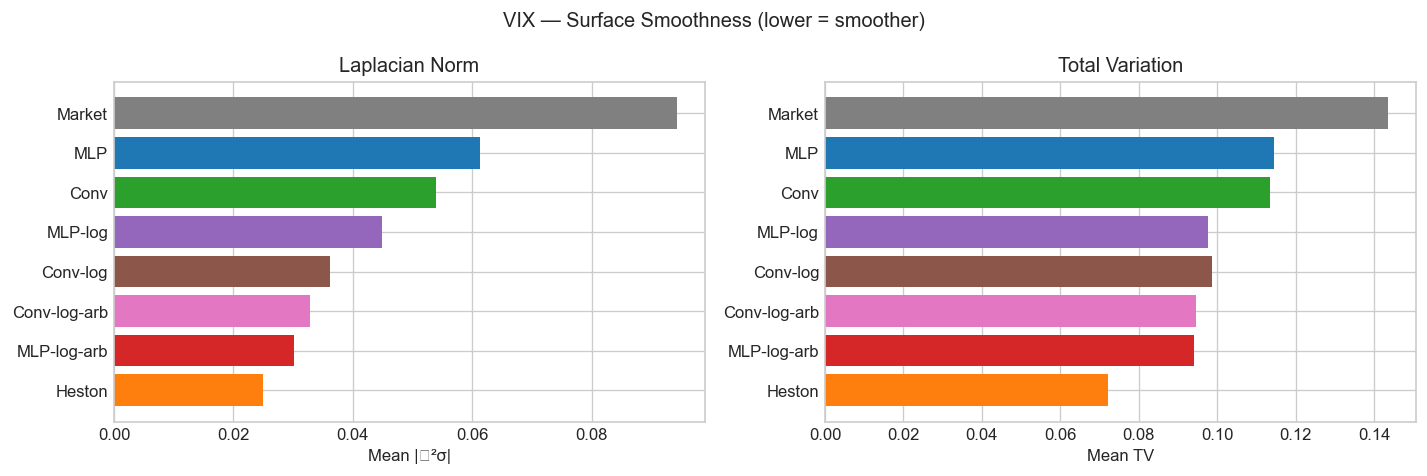

In [18]:
def laplacian_norm(surfaces):
    lap_mat = np.diff(surfaces, n=2, axis=2)
    lap_del = np.diff(surfaces, n=2, axis=3)
    return np.nanmean(np.abs(lap_mat)) + np.nanmean(np.abs(lap_del))

def total_variation(surfaces):
    dx = np.diff(surfaces, axis=2)
    dy = np.diff(surfaces, axis=3)
    return np.nanmean(np.abs(dx)) + np.nanmean(np.abs(dy))

smooth_rows = []
all_surfs_smooth = {**models, "Market": market}
for name, surf in all_surfs_smooth.items():
    smooth_rows.append({"Surface": name, "Laplacian |∇²σ|": laplacian_norm(surf),
                        "Total Variation": total_variation(surf)})

smooth_df = pd.DataFrame(smooth_rows).set_index("Surface").sort_values("Laplacian |∇²σ|")
smooth_df.to_csv(OUT / "tables" / "smoothness.csv")
print(f"{TICKER} — Surface Smoothness (lower = smoother):")
display(smooth_df.round(6))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
names = smooth_df.index.tolist()
colors = [COLOURS.get(n, "grey") for n in names]
ax1.barh(names, smooth_df["Laplacian |∇²σ|"], color=colors)
ax1.set_xlabel("Mean |∇²σ|")
ax1.set_title("Laplacian Norm")
ax2.barh(names, smooth_df["Total Variation"], color=colors)
ax2.set_xlabel("Mean TV")
ax2.set_title("Total Variation")
fig.suptitle(f"{TICKER} — Surface Smoothness (lower = smoother)")
fig.tight_layout()
fig.savefig(OUT / "plots" / "smoothness.png", bbox_inches="tight", dpi=150)
plt.show()

## Summary

All validation artifacts saved to `artifacts/validation/VIX/`:
- `plots/` — PNG figures
- `tables/` — CSV tables

**Key outputs:**
| File | Content |
|------|---------|
| `error_distribution_stats.csv` | Percentile table (P50–P99, max, skew, kurtosis) |
| `mape_summary.csv` | MAPE overall vs high/low IV subsets |
| `ks_test_summary.csv` | KS rejection rates per model |
| `dm_tstat.csv`, `dm_pval.csv` | Diebold-Mariano pairwise matrices |
| `backtest_quantile.csv` | Kupiec POF + traffic light |
| `backtest_fixed_threshold.csv` | Fixed threshold exceedance rates |
| `regime_mae.csv` | MAE by vol regime tercile |
| `arbitrage_violations.csv` | Calendar + butterfly violation counts |
| `smoothness.csv` | Laplacian + TV rankings |